In [92]:
import os
import math
from graphviz import Digraph

In [94]:
root_dir = r"C:\Users\Trish\Documents\CMU\INFO VIZ\CMU-MS-DAS-Vis-S26\docs"
nodes = {}

In [96]:
def get_label(path):
    name = os.path.basename(path)
    if name == '':
        return '.'
    if len(name) <= 10:
        return name
    return name[:7] + '...'


def show_this_leaf(name):
    if name.startswith('.') or name.startswith('_'):
        return False
    if name.endswith('~'):
        return False
    if name.startswith('#') and name.endswith('#'):
        return False
    return True


def add_descendant_to_all_ancestors(node_key):
    while node_key is not None:
        nodes[node_key]['descendant_count'] += 1
        node_key = nodes[node_key]['parent']

In [98]:
for root, dirs, files in os.walk(root_dir):
    rel_root = os.path.relpath(root, root_dir)
    if rel_root == '.':
        parent = None
    else:
        parent = os.path.dirname(rel_root)
        if parent == '':
            parent = '.'

    # Add directory node
    if rel_root not in nodes:
        nodes[rel_root] = {
            'parent': parent,
            'descendant_count': 0,
            'is_dir': True
        }

    # Add subdirectories
    for d in dirs:
        rel_path = os.path.join(rel_root, d)
        nodes[rel_path] = {
            'parent': rel_root,
            'descendant_count': 0,
            'is_dir': True
        }

    # Add files
    for f in files:
        if not show_this_leaf(f):
            continue

        rel_path = os.path.join(rel_root, f)

        nodes[rel_path] = {
            'parent': rel_root,
            'descendant_count': 0,
            'is_dir': False
        }

        # Increment ancestors for THIS FILE
        add_descendant_to_all_ancestors(rel_root)

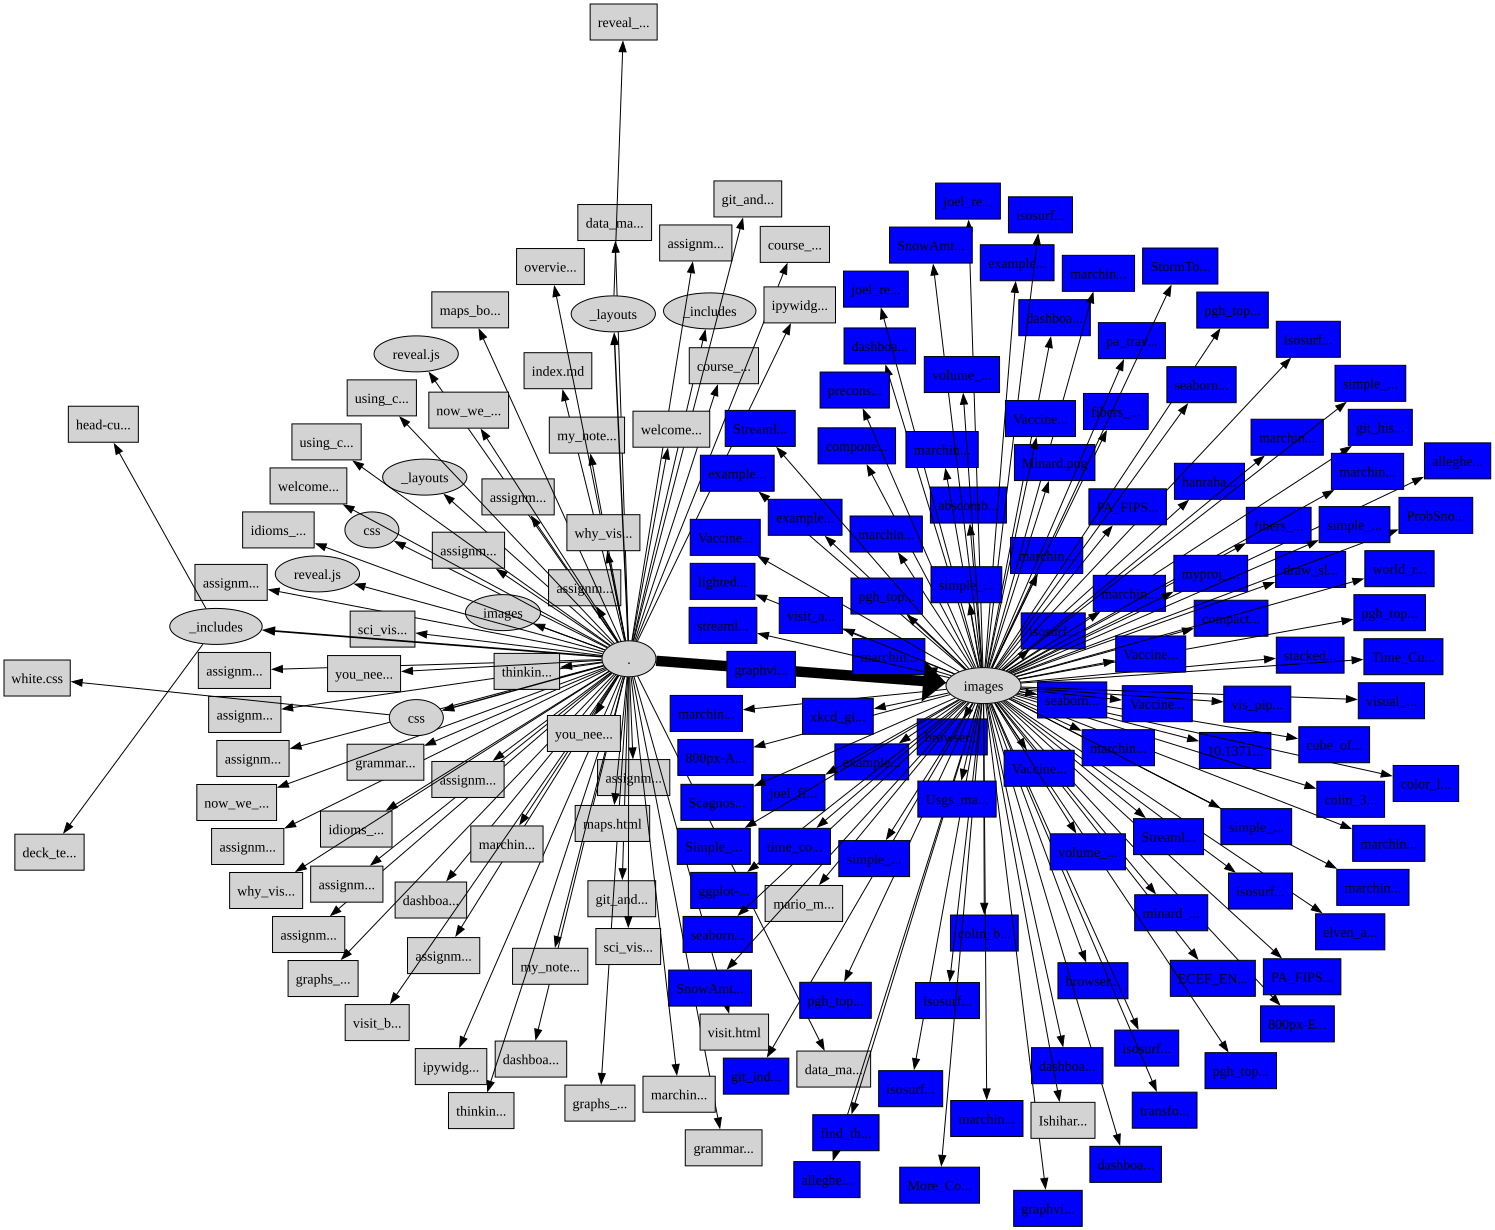

In [100]:
dot = Digraph('G', engine='neato')
dot.attr(overlap='false')
dot.attr('node', style='filled')

for path, data in nodes.items():

    label = get_label(path)

    # Shape
    shape = 'ellipse' if data['is_dir'] else 'box'

    # Color
    if path.endswith(('.png', '.jpg', '.svg')):
        fillcolor = 'blue'
    else:
        fillcolor = 'lightgray'

    dot.node(path, label=label, shape=shape, fillcolor=fillcolor)

    # Edge to parent
    if data['parent'] is not None:
        width = math.sqrt(data['descendant_count'] + 1)
        dot.edge(data['parent'], path, penwidth=str(width))
dot

In [108]:
output_path = os.path.join(r"C:\Users\Trish\Documents\CMU\INFO VIZ\HW5", "graphviz_directory_graph.dot")
dot.save(output_path)

'C:\\Users\\Trish\\Documents\\CMU\\INFO VIZ\\HW5\\graphviz_directory_graph.dot'